# Song rating simulated-data analysis

This notebook reads the PsyNet simulated export directly and checks that the audio prescreen and song-rating data paths were populated. The data come from bots and validate workflow only; they do not support conclusions about human music preferences.

In [1]:
from pathlib import Path
import pandas as pd

candidates = [
    Path('code/song_rating_experiment/data/simulated_data/regular/basic_data'),
    Path('../../code/song_rating_experiment/data/simulated_data/regular/basic_data'),
]
export_dir = next(path for path in candidates if path.exists())

trial = pd.read_csv(export_dir / 'trial.csv')
participant = pd.read_csv(export_dir / 'participant.csv')

ratings = trial[trial['trial_maker_id'] == 'song_ratings'].copy()
prescreen = trial[trial['trial_maker_id'] == 'audio_prescreen'].copy()
ratings['rating'] = pd.to_numeric(ratings['rating'])

summary = pd.DataFrame({
    'participants': [participant['participant_id'].nunique()],
    'prescreen_trials': [len(prescreen)],
    'rating_trials': [len(ratings)],
    'unique_tracks_rated': [ratings['track_id'].nunique()],
    'ratings_per_participant_min': [ratings.groupby('participant_id').size().min()],
    'ratings_per_participant_max': [ratings.groupby('participant_id').size().max()],
    'all_prescreens_passed': [participant['audio_prescreen_passed'].all()],
})
summary

,participants,prescreen_trials,rating_trials,unique_tracks_rated,ratings_per_participant_min,ratings_per_participant_max,all_prescreens_passed
0,3,9,90,30,30,30,True


,track_id,n_ratings,mean_rating
0,-----hv6k5by,3,5.0
1,--smoke--,3,5.0
2,-_-dj_wl_will_edit_later-8kgul,3,5.0
3,-_-dj_wl_will_edit_later-qce2td,3,5.0
4,-_404_dj_mixcraft_remix,3,5.0
5,-_fast_dj_collab,3,5.0
6,-_fast_do_i,3,5.0
7,-_get_lucky_remix,3,5.0
8,-_rap_beat,3,5.0
9,-_sup_nova_-,3,5.0


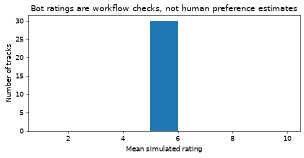

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 50

track_summary = (
    ratings.groupby('track_id')
    .agg(n_ratings=('rating', 'size'), mean_rating=('rating', 'mean'))
    .reset_index()
    .sort_values('track_id')
)

display(track_summary.head(10))

fig, ax = plt.subplots(figsize=(7, 3))
track_summary['mean_rating'].plot(kind='hist', bins=range(1, 11), ax=ax)
ax.set_xlabel('Mean simulated rating')
ax.set_ylabel('Number of tracks')
ax.set_title('Bot ratings are workflow checks, not human preference estimates')
plt.show()

## Interpretation

The simulated export contains three approved bot participants. Each bot passed the audio prescreen and completed 30 song-rating trials, producing 90 total ratings across the 30 S3-backed tracks. The ratings are deterministic bot responses used to validate data plumbing, trial counts, and export fields; they should not be interpreted as evidence about real listeners' song preferences.